In [1]:
#Logistic Regression using the Covid data set

import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('corona_tested_individuals_ver_006.english.csv')

/tmp/ipykernel_47543/3345102046.py:1: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('corona_tested_individuals_ver_006.english.csv')


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 21.3 MB


In [4]:
df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [5]:
df['test_date'] = pd.to_datetime(df['test_date'])

In [6]:
#Removing other from data set
df =df[
    df['corona_result'].isin(
        ['positive', 'negative']
    )
]

In [7]:
df['corona_result'].value_counts()

corona_result
negative    260227
positive     14729
Name: count, dtype: int64

In [8]:
#binary for reusults
df['corona_result'] = df['corona_result'].map(
    {
        'negative': 0,
        'positive': 1
    }
)

In [9]:
df['corona_result'].value_counts()

corona_result
0    260227
1     14729
Name: count, dtype: int64

In [10]:
df['gender'] = df['gender'].fillna('Missing')

df['gender'].value_counts(dropna=False)

gender
female     128541
male       127370
Missing     19045
Name: count, dtype: int64

In [11]:
df['age_60_and_above'] = df['age_60_and_above'].fillna('Missing')

df['age_60_and_above'].value_counts(dropna=False)

age_60_and_above
Missing    125664
No         123867
Yes         25425
Name: count, dtype: int64

In [12]:
symptoms = [
    'cough',
    'fever',
    'sore_throat',
    'shortness_of_breath',
    'head_ache'
]

df[symptoms] = df[symptoms].fillna(0)

In [13]:
df[symptoms].isnull().sum()

cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
dtype: int64

In [14]:
df.isnull().sum()

test_date              0
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
corona_result          0
age_60_and_above       0
gender                 0
test_indication        0
dtype: int64

In [15]:
print(df['gender'].unique())
print(df['age_60_and_above'].unique())
print(df['test_indication'].unique())

<StringArray>
['female', 'male', 'Missing']
Length: 3, dtype: str
<StringArray>
['Missing', 'Yes', 'No']
Length: 3, dtype: str
<StringArray>
['Other', 'Abroad', 'Contact with confirmed']
Length: 3, dtype: str


In [16]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'gender',
        'age_60_and_above',
        'test_indication'
    ],
    drop_first=True
)

In [17]:
df_encoded = df_encoded.astype({
    'gender_female': int,
    'gender_male': int,
    'age_60_and_above_No': int,
    'age_60_and_above_Yes': int,
    'test_indication_Contact with confirmed': int,
    'test_indication_Other': int
})

In [18]:
df_encoded.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,gender_female,gender_male,age_60_and_above_No,age_60_and_above_Yes,test_indication_Contact with confirmed,test_indication_Other
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,0,0,1,0,0,0,1
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,0,0,1,0,0,0,1


In [19]:
df_encoded.columns

Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'gender_female', 'gender_male',
       'age_60_and_above_No', 'age_60_and_above_Yes',
       'test_indication_Contact with confirmed', 'test_indication_Other'],
      dtype='str')

In [20]:
X = df_encoded.drop(
    columns=[
        'corona_result',
        'test_date'
    ]
)

y = df_encoded['corona_result']

In [21]:
X.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,gender_female,gender_male,age_60_and_above_No,age_60_and_above_Yes,test_indication_Contact with confirmed,test_indication_Other
0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0,1
1,1.0,0.0,0.0,0.0,0.0,1,0,0,0,0,1
2,0.0,1.0,0.0,0.0,0.0,0,1,0,0,0,1
3,1.0,0.0,0.0,0.0,0.0,1,0,0,0,0,1
4,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,1


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [25]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [26]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (192469, 11)
Validation: (41243, 11)
Test: (41244, 11)


In [27]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42,
    stratify=y_test
)

In [28]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (192469, 11)
Validation: (20622, 11)
Test: (20622, 11)


In [29]:
print("Training")
print(y_train.value_counts(normalize=True))

print("\nValidation")
print(y_val.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Training
corona_result
0    0.946433
1    0.053567
Name: proportion, dtype: float64

Validation
corona_result
0    0.946416
1    0.053584
Name: proportion, dtype: float64

Test
corona_result
0    0.946416
1    0.053584
Name: proportion, dtype: float64


In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [31]:
val_pred = lr_model.predict(X_val)

val_pred_proba = lr_model.predict_proba(X_val)[:, 1]

In [32]:
from sklearn.metrics import roc_auc_score

val_auc = roc_auc_score(
    y_val,
    val_pred_proba
)

print(f"Validation ROC-AUC: {val_auc:.4f}")

Validation ROC-AUC: 0.8849


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_val, val_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     19517
           1       0.76      0.53      0.63      1105

    accuracy                           0.97     20622
   macro avg       0.87      0.76      0.80     20622
weighted avg       0.96      0.97      0.96     20622



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_pred)

cm

array([[19327,   190],
       [  516,   589]])

In [35]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
4,head_ache,4.563317
9,test_indication_Contact with confirmed,3.738276
2,sore_throat,2.882709
3,shortness_of_breath,2.816020
1,fever,1.466598
8,age_60_and_above_Yes,1.091423
7,age_60_and_above_No,0.519058
6,gender_male,0.477188
5,gender_female,0.179425
0,cough,0.016537


In [36]:
test_pred = lr_model.predict(X_test)

test_pred_proba = lr_model.predict_proba(X_test)[:, 1]

In [37]:
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(
    y_test,
    test_pred_proba
)

print(f"Test ROC-AUC: {test_auc:.4f}")

Test ROC-AUC: 0.9035


In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_pred
))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     19517
           1       0.75      0.51      0.61      1105

    accuracy                           0.96     20622
   macro avg       0.86      0.75      0.79     20622
weighted avg       0.96      0.96      0.96     20622



In [39]:
from sklearn.metrics import confusion_matrix

test_cm = confusion_matrix(
    y_test,
    test_pred
)

print(test_cm)

[[19327   190]
 [  542   563]]


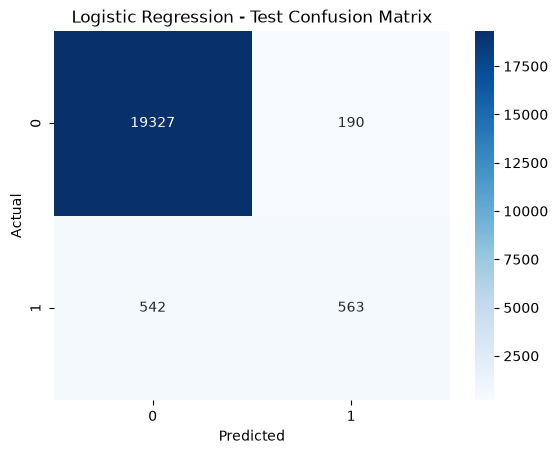

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [41]:
print(f"Validation ROC-AUC: {val_auc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Validation ROC-AUC: 0.8849
Test ROC-AUC: 0.9035


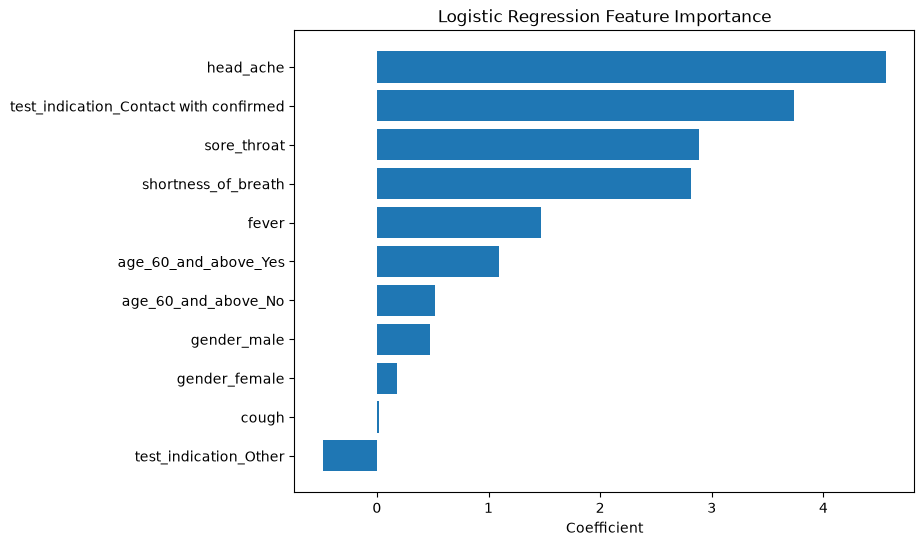

In [58]:
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=True
)

plt.figure(figsize=(8,6))
plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.title('Logistic Regression Feature Importance')
plt.xlabel('Coefficient')
plt.show()

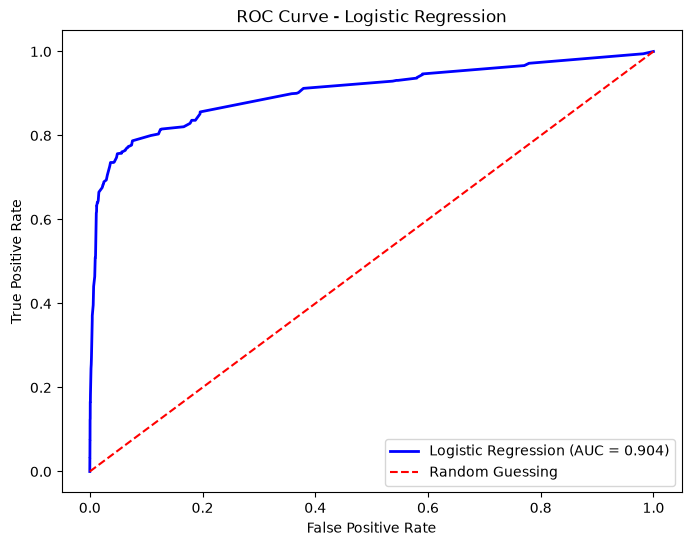

In [42]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_pred_proba
)

# Create Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color='blue',
    linewidth=2,
    label=f'Logistic Regression (AUC = {test_auc:.3f})'
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    color='red',
    linestyle='--',
    label='Random Guessing'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')

plt.show()

In [ ]:
#Final